In [1]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

c:\Users\Anton Wijaya\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv(
    "../../../data/eval_results_deepseek.csv",
    sep=";",
    engine="python",
    on_bad_lines="skip"
)

In [3]:
model = SentenceTransformer("all-MiniLM-L6-v2")

In [4]:
question_emb = model.encode(df["question"].tolist())
answer_emb = model.encode(df["answer"].tolist())

In [5]:
similarities = [
    cosine_similarity([q], [a])[0][0]
    for q, a in zip(question_emb, answer_emb)
]

In [6]:
df["similarity_score"] = similarities
df[["question", "answer", "similarity_score"]].head(100)

,question,answer,similarity_score
0,Laptop apa yang cocok untuk gaming budget 15 j...,"Berdasarkan data produk yang tersedia, **tidak...",0.690142
1,"Laptop ringan untuk kuliah, RAM minimal 8GB","Berdasarkan data yang tersedia, berikut rekome...",0.609188
2,"Saya punya budget 8 juta, laptop apa yang pali...","Berdasarkan informasi produk yang tersedia, la...",0.736616
3,Lebih baik pilih laptop dengan SSD 512GB atau ...,"Berdasarkan informasi produk yang tersedia, un...",0.791950
4,Laptop apa yang cocok untuk kerja kantoran ful...,"Berdasarkan informasi produk yang tersedia, be...",0.813107
...,...,...,...
95,"Kalau saya punya budget 10 juta, sebaiknya pil...","Berdasarkan data produk yang tersedia, tidak a...",0.750728
96,Laptop apa yang cocok untuk mahasiswa teknik s...,"Berdasarkan informasi produk yang tersedia, be...",0.637035
97,Saya ingin laptop yang enak dipakai untuk kons...,"Berdasarkan informasi produk yang tersedia, be...",0.752976
98,Laptop apa yang cocok untuk developer fullstac...,"Maaf, datanya belum cukup.\r\n\r\nBerdasarkan ...",0.778257


In [7]:
THRESHOLD = 0.5

df["predicted_relevant"] = df["similarity_score"] >= THRESHOLD
df["is_relevant"] = (df["similarity_score"] >= THRESHOLD).astype(int)

In [8]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(df["is_relevant"], df["predicted_relevant"])
print(cm)

print(classification_report(df["is_relevant"], df["predicted_relevant"]))

[[ 1  0]
 [ 0 99]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00        99

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



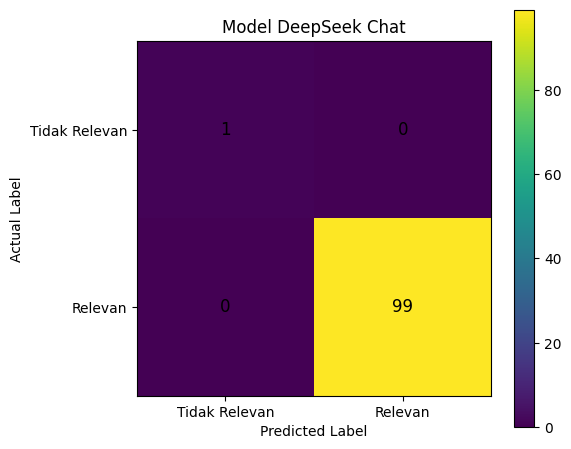

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Model DeepSeek Chat")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0,1], ["Tidak Relevan", "Relevan"])
plt.yticks([0,1], ["Tidak Relevan", "Relevan"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)

plt.colorbar()
plt.tight_layout()
plt.show()